https://github.com/cospectrum/scrfd

https://github.com/cospectrum/scrfd/tree/main/scrfd-python

https://chatgpt.com/c/6abd4398-1710-83ee-a7c4-2fd9a6e9c7b0



In [1]:
from scrfd import SCRFD, Threshold
from PIL import Image

In [4]:
face_detector = SCRFD.from_path("../models/scrfd.onnx")
threshold = Threshold(probability=0.4)

image = Image.open("../raw_data/solvay_conference_1927.png").convert("RGB")
faces = face_detector.detect(image, threshold=threshold)

for face in faces:
    bbox = face.bbox
    kps = face.keypoints
    score = face.probability
    print(f"{bbox=}, {kps=}, {score=}")

bbox=Bbox(upper_left=Point(x=2084.703857421875, y=846.1289672851562), lower_right=Point(x=2165.553955078125, y=951.1995239257812)), kps=FaceKeypoints(left_eye=Point(x=2101.814453125, y=887.5723266601562), right_eye=Point(x=2139.595458984375, y=887.1728515625), nose=Point(x=2118.366455078125, y=908.5358276367188), left_mouth=Point(x=2105.2861328125, y=924.7944946289062), right_mouth=Point(x=2136.664306640625, y=924.4807739257812)), score=0.8618062734603882
bbox=Bbox(upper_left=Point(x=2295.755126953125, y=839.0408935546875), lower_right=Point(x=2373.671875, y=938.2667846679688)), kps=FaceKeypoints(left_eye=Point(x=2312.01318359375, y=883.399658203125), right_eye=Point(x=2346.101806640625, y=876.7390747070312), nose=Point(x=2330.9072265625, y=900.37744140625), left_mouth=Point(x=2322.707763671875, y=916.9165649414062), right_mouth=Point(x=2350.2451171875, y=911.8145751953125)), score=0.8615951538085938
bbox=Bbox(upper_left=Point(x=855.47802734375, y=1142.321533203125), lower_right=Point(

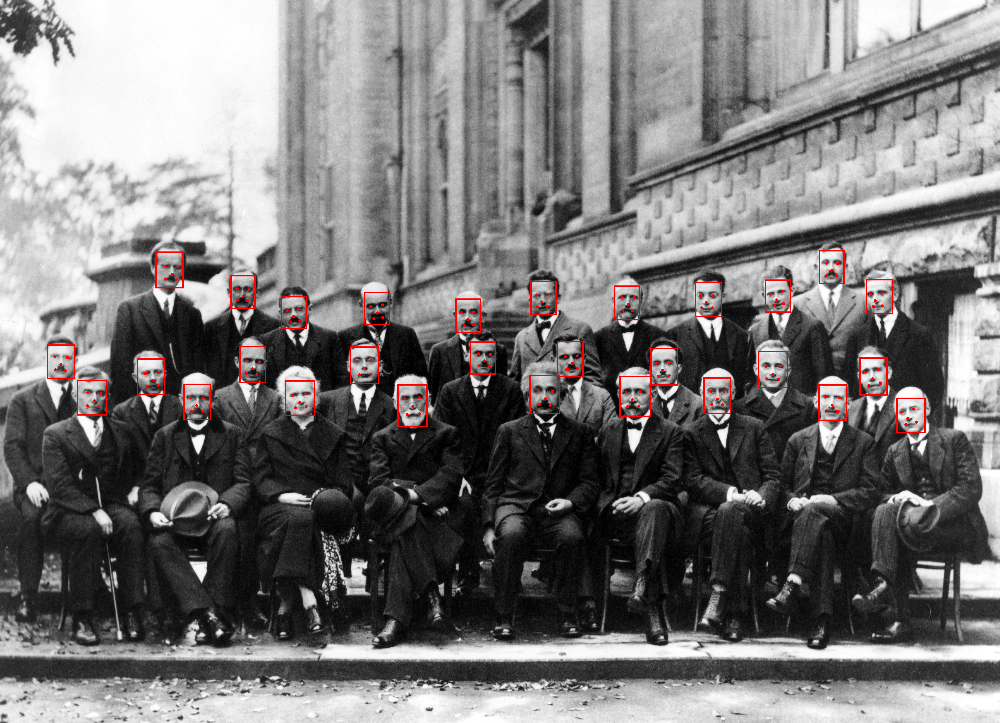

In [6]:
from common import draw_faces
img = draw_faces(image, faces)
img

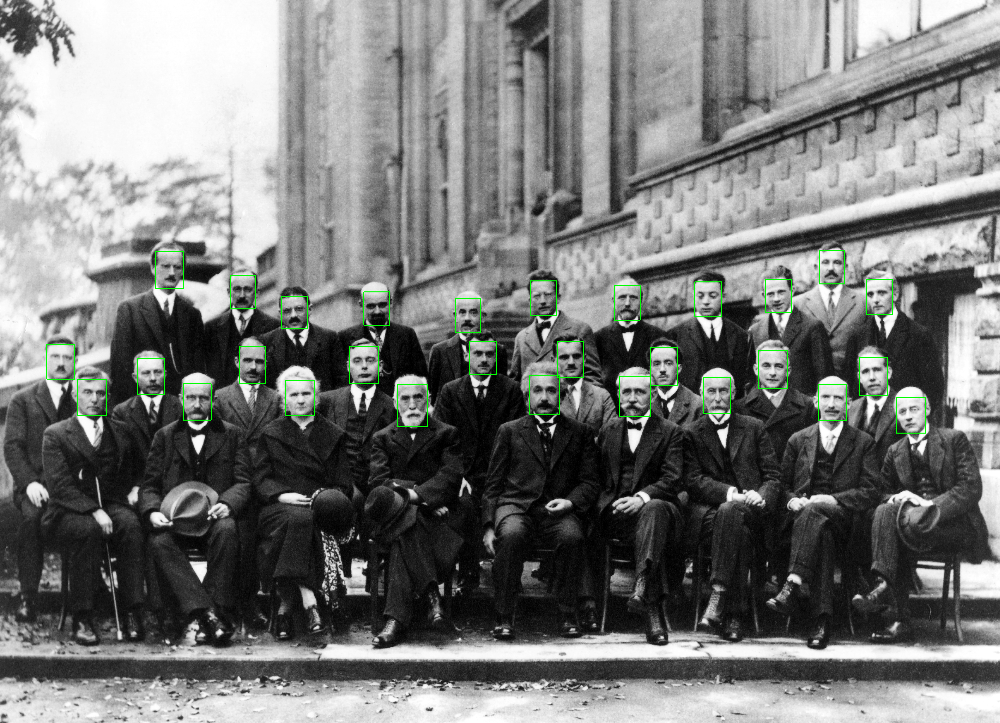

In [9]:
import cv2
import numpy as np
from PIL import Image

def draw_faces_local(image, faces):
    """
    Tailored replacement for drawing faces that extracts coordinates 
    from Pydantic Bbox objects using upper_left and lower_right properties.
    """
    # Convert PIL Image to OpenCV NumPy array if necessary
    is_pil = isinstance(image, Image.Image)
    if is_pil:
        img_cv = np.array(image)
        img_cv = cv2.cvtColor(img_cv, cv2.COLOR_RGB2BGR)
    else:
        img_cv = image.copy()

    for face in faces:
        if not hasattr(face, 'bbox') or face.bbox is None:
            continue
            
        b = face.bbox
        
        # Extract coordinates using upper_left and lower_right attributes
        try:
            # Safely handle if upper_left and lower_right have .x and .y attributes
            x1 = int(b.upper_left.x)
            y1 = int(b.upper_left.y)
            x2 = int(b.lower_right.x)
            y2 = int(b.lower_right.y)
        except AttributeError:
            try:
                # Fallback: if upper_left and lower_right act like indexable tuples/lists [x, y]
                x1, y1 = int(b.upper_left[0]), int(b.upper_left[1])
                x2, y2 = int(b.lower_right[0]), int(b.lower_right[1])
            except Exception:
                print(f"Skipping a face. upper_left structure: {dir(b.upper_left)}")
                continue

        # 1. Draw Bounding Box (Green Rectangle)
        cv2.rectangle(img_cv, (x1, y1), (x2, y2), (0, 255, 0), 2)
        
        # 2. Draw Keypoints / Landmarks if they exist
        if hasattr(face, 'kps') and face.kps is not None:
            try:
                for kp in face.kps:
                    # Dynamically handle Pydantic keypoint objects vs raw lists
                    kx = int(kp.x) if hasattr(kp, 'x') else int(kp[0])
                    ky = int(kp.y) if hasattr(kp, 'y') else int(kp[1])
                    cv2.circle(img_cv, (kx, ky), 3, (0, 0, 255), -1)
            except Exception:
                pass # Skip landmarks if structure differs wildly
                
    # Convert back to PIL Image if input was PIL
    if is_pil:
        return Image.fromarray(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
    return img_cv

# --- Run your detection rendering ---
img = draw_faces_local(image, faces)
img
